In [7]:
# Cell 1: Package Dependencies Installation (With bypass flag)
!pip3 install --break-system-packages matplotlib seaborn scikit-learn torch pandas numpy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 2.9 MB/s  0:00:02 eta 0:00:010:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 5.2 MB/s  0:00:01m 5.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 4.1 MB/s  0:00:21 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.4 MB/s  0:00:00m 5.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 3.8 MB/s  0:00:023.8 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━

>>> Dropping metadata identifiers: ['device_name', 'device_mac', 'timestamp']
>>> Dropping highly correlated redundant features (|r| > 0.85): ['timestamp_end', 'log_data-ranges_max', 'log_data-ranges_min', 'log_data-types_count', 'network_header-length_max', 'network_header-length_min', 'network_ip-flags_max', 'network_ip-length_min', 'network_ip-length_std_deviation', 'network_ips_dst_count', 'network_ips_src', 'network_ips_src_count', 'network_macs_all_count', 'network_macs_dst_count', 'network_macs_src', 'network_macs_src_count', 'network_mss_max', 'network_mss_min', 'network_packet-size_max', 'network_packet-size_std_deviation', 'network_packets_dst_count', 'network_packets_src_count', 'network_payload-length_avg', 'network_payload-length_max', 'network_payload-length_min', 'network_payload-length_std_deviation', 'network_ports_dst', 'network_ports_src', 'network_ports_src_count', 'network_protocols_dst_count', 'network_protocols_src_count', 'network_tcp-flags-ack_count', 'network_

/var/folders/25/s5kmh86923q9llc_sj429pdr0000gn/T/ipykernel_30711/1404835186.py:54: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in full_df.select_dtypes(include=['object', 'category']).columns:


    Epoch 01/20 | Sequence Reconstruction Loss: 0.077056
    Epoch 05/20 | Sequence Reconstruction Loss: 0.050080
    Epoch 10/20 | Sequence Reconstruction Loss: 0.048690
    Epoch 15/20 | Sequence Reconstruction Loss: 0.048273
    Epoch 20/20 | Sequence Reconstruction Loss: 0.048101

>>> Extracting Combined Temporal-Point Feature Ensembles...
>>> Fitting Isolation Forest Engine on Pure Normal Data Profiles...

    ONE-CLASS PIPELINE PROCESSING COMPLETE
Remaining Feature Count:                  39
Maximum Anomaly Score seen in Test Split: 0.1254
Minimum Anomaly Score seen in Test Split: -0.1360
Mean Anomaly Score of Normal Traffic:     -0.0891
Extracted Hidden Layers Shape:            (5993, 32)

>>> Generating Hidden Layer Activation Map...


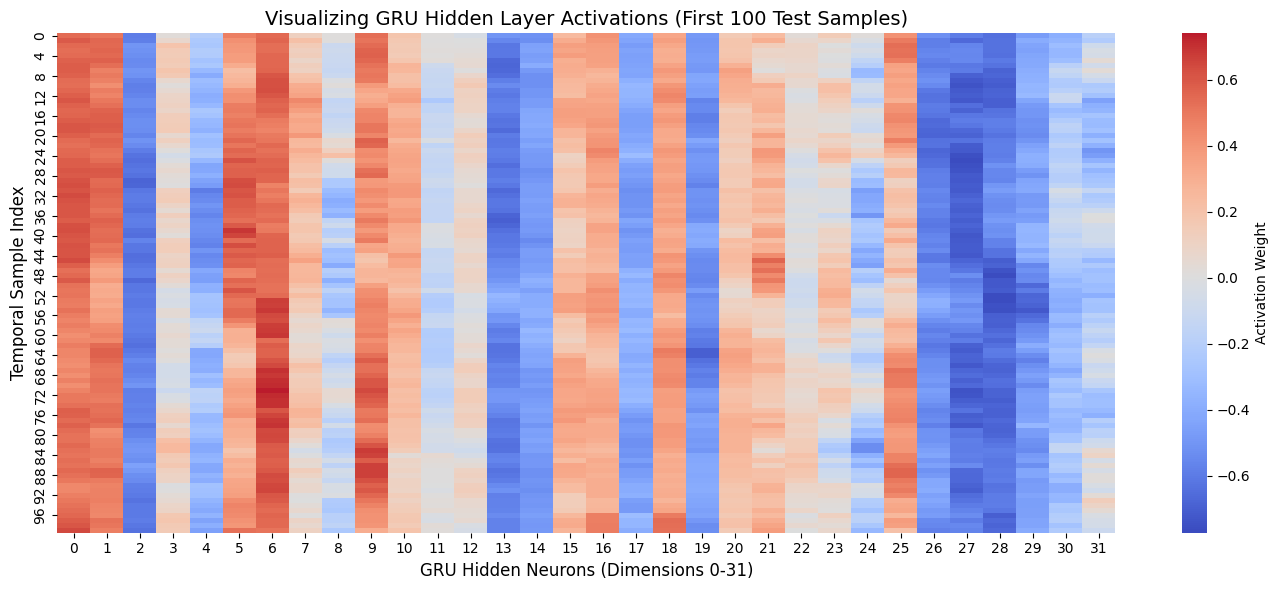

In [10]:
# Cell 2: Implementation and Execution Pipeline (With MinMax Scaling & Visualization)
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler  # Changed for strict 0-1 bounding
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reproducibility Configuration
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# 2. Dataset Engine with Metadata and High Correlation Drops
def load_and_clean_data(data_path='./datasets/', samples_per_file=10000, correlation_threshold=0.85):
    files = {
        'b5': 'benign_samples_5sec.csv', 
        'b10': 'benign_samples_10sec.csv'
    }
    dfs = []
    for key, fname in files.items():
        path = os.path.join(data_path, fname)
        if not os.path.exists(path): 
            continue
        temp_df = pd.read_csv(path)
        temp_df = temp_df.sample(n=min(samples_per_file, len(temp_df)), random_state=42)
        temp_df["label"] = 0  
        dfs.append(temp_df)

    if not dfs:
        raise FileNotFoundError("No benign dataset files discovered within target directories.")

    full_df = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Step A: Metadata Filtering Block
    drop_cols = ['device_name', 'device_mac', 'device_id', 'ip', 'timestamp']
    existing_drop_cols = [col for col in drop_cols if col in full_df.columns]
    if existing_drop_cols:
        print(f">>> Dropping metadata identifiers: {existing_drop_cols}")
        full_df = full_df.drop(columns=existing_drop_cols)
    
    # Step B: Encode non-numeric/categorical variables to codes
    for col in full_df.select_dtypes(include=['object', 'category']).columns:
        if col != "label":
            full_df[col] = full_df[col].astype("category").cat.codes

    # Step C: Correlation Filtering Block
    feature_df = full_df.drop(columns=["label"], errors="ignore")
    corr_matrix = feature_df.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > correlation_threshold)]
    
    if to_drop:
        print(f">>> Dropping highly correlated redundant features (|r| > {correlation_threshold}): {to_drop}")
        full_df = full_df.drop(columns=to_drop)
    
    # Step D: Drop zero variance columns
    feature_cols = [col for col in full_df.columns if col != "label"]
    non_zero_var_cols = [col for col in feature_cols if (full_df[col] != full_df[col].iloc[0]).any()]
    full_df = full_df[non_zero_var_cols + ["label"]]
            
    return full_df

# 3. GRU Temporal Feature Extractor Backbone Network
class GRUFeatureExtractor(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True
        )
        self.decoder = nn.Linear(hidden_dim, input_dim)
        
    def forward(self, x):
        out, h_n = self.gru(x)
        hidden_context = h_n[-1] 
        reconstructed = self.decoder(hidden_context).unsqueeze(1).repeat(1, x.size(1), 1)
        return reconstructed, hidden_context

# 4. Cascaded Pipeline Orchestrator 
class CascadedIoTDetector:
    def __init__(self, input_dim, hidden_dim=32, window_size=8, contamination=0.01):
        self.input_dim = input_dim
        self.window_size = window_size
        self.hidden_dim = hidden_dim
        
        self.feature_extractor = GRUFeatureExtractor(input_dim, hidden_dim)
        self.anomaly_classifier = IsolationForest(
            n_estimators=300,
            max_samples=0.8,
            contamination=contamination,
            random_state=42,
            n_jobs=-1
        )
        
    def create_sliding_windows(self, data):
        sequences = []
        for i in range(len(data) - self.window_size + 1):
            sequences.append(data[i : i + self.window_size])
        return np.array(sequences)

    def fit_backbone(self, X_train_scaled, epochs=20, batch_size=256, lr=0.002):
        X_seq = self.create_sliding_windows(X_train_scaled)
        
        dataset = TensorDataset(torch.FloatTensor(X_seq))
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        optimizer = torch.optim.Adam(self.feature_extractor.parameters(), lr=lr)
        criterion = nn.MSELoss()
        
        print(">>> Beginning GRU Feature Extractor Training Pipeline (Benign Only)...")
        self.feature_extractor.train()
        for epoch in range(epochs):
            total_loss = 0
            for batch in dataloader:
                inputs = batch[0]
                optimizer.zero_grad()
                reconstructed, _ = self.feature_extractor(inputs)
                loss = criterion(reconstructed, inputs)
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * inputs.size(0)
            
            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"    Epoch {epoch+1:02d}/{epochs:02d} | Sequence Reconstruction Loss: {total_loss/len(dataset):.6f}")

    def extract_fused_features(self, X_scaled):
        X_seq = self.create_sliding_windows(X_scaled)
        
        self.feature_extractor.eval()
        with torch.no_grad():
            _, hidden_embeddings = self.feature_extractor(torch.FloatTensor(X_seq))
            hidden_embeddings = hidden_embeddings.numpy()
            
        point_features = X_scaled[self.window_size - 1 :]
        fused_features = np.hstack((point_features, hidden_embeddings))
        return fused_features, hidden_embeddings

    def fit_ensemble(self, X_train_scaled):
        print("\n>>> Extracting Combined Temporal-Point Feature Ensembles...")
        fused_train, _ = self.extract_fused_features(X_train_scaled)
        print(">>> Fitting Isolation Forest Engine on Pure Normal Data Profiles...")
        self.anomaly_classifier.fit(fused_train)

    def compute_anomaly_scores(self, X_test_scaled):
        fused_features, hidden_embeddings = self.extract_fused_features(X_test_scaled)
        scores = -self.anomaly_classifier.decision_function(fused_features)
        pad_length = self.window_size - 1
        padded_scores = np.concatenate([np.repeat(scores[0], pad_length), scores])
        return padded_scores, hidden_embeddings

# ==================================================
# 5. Pipeline Execution 
# ==================================================
if __name__ == "__main__":
    # Load dataset
    df = load_and_clean_data(correlation_threshold=0.85) 
    X_raw = df.drop("label", axis=1, errors="ignore").fillna(0).values
    
    # CRITICAL FIX: Scale data using MinMaxScaler to keep everything between 0 and 1
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    # Train/Test Split on scaled data
    X_train, X_test = train_test_split(X_scaled, test_size=0.3, random_state=42)
    
    print(f">>> Training Baseline Size (Pure Benign): {X_train.shape[0]} samples")
    print(f">>> Testing Evaluation Size (Pure Benign Verification): {X_test.shape[0]} samples")

    # Pipeline Model Initialization
    pipeline = CascadedIoTDetector(input_dim=X_scaled.shape[1], hidden_dim=32, window_size=8, contamination=0.01)
    
    # Fit models
    pipeline.fit_backbone(X_train, epochs=20, batch_size=256, lr=0.002)
    pipeline.fit_ensemble(X_train)

    # Score models and extract the learned hidden layer matrix
    benign_test_scores, test_hidden_layers = pipeline.compute_anomaly_scores(X_test)
    
    print("\n" + "="*50 + "\n    ONE-CLASS PIPELINE PROCESSING COMPLETE\n" + "="*50)
    print(f"Remaining Feature Count:                  {X_scaled.shape[1]}")
    print(f"Maximum Anomaly Score seen in Test Split: {benign_test_scores.max():.4f}")
    print(f"Minimum Anomaly Score seen in Test Split: {benign_test_scores.min():.4f}")
    print(f"Mean Anomaly Score of Normal Traffic:     {benign_test_scores.mean():.4f}")
    print(f"Extracted Hidden Layers Shape:            {test_hidden_layers.shape}\n")

    # ==================================================
    # 6. VISUALIZE HIDDEN LAYER
    # ==================================================
    print(">>> Generating Hidden Layer Activation Map...")
    samples_to_plot = min(100, len(test_hidden_layers)) 
    
    plt.figure(figsize=(14, 6))
    sns.heatmap(
        test_hidden_layers[:samples_to_plot], 
        cmap="coolwarm", 
        center=0,
        cbar_kws={'label': 'Activation Weight'}
    )
    plt.title(f"Visualizing GRU Hidden Layer Activations (First {samples_to_plot} Test Samples)", fontsize=14)
    plt.xlabel("GRU Hidden Neurons (Dimensions 0-31)", fontsize=12)
    plt.ylabel("Temporal Sample Index", fontsize=12)
    plt.tight_layout()
    plt.show()

>>> Extracting Attack Sample Data Pools...


/var/folders/25/s5kmh86923q9llc_sj429pdr0000gn/T/ipykernel_30711/53434042.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in raw_attack_df.select_dtypes(include=['object', 'category']).columns:


    • Mixed Evaluation Pool Size: 12000 samples
      - Normal Verification Baselines: 6000
      - Unseen Attack Instances:        6000

>>> Streaming Mixed Test Vectors to Trained Cascaded Framework...

   CASCADED ONE-CLASS DETECTION REPORT (WITH ATTACKS)
              precision    recall  f1-score   support

      Normal     0.9993    0.9983    0.9988      6000
      Attack     0.9983    0.9993    0.9988      6000

    accuracy                         0.9988     12000
   macro avg     0.9988    0.9988    0.9988     12000
weighted avg     0.9988    0.9988    0.9988     12000

Area Under ROC Curve (ROC-AUC Score): 0.9999
Calculated Optimal Threshold:       0.0593


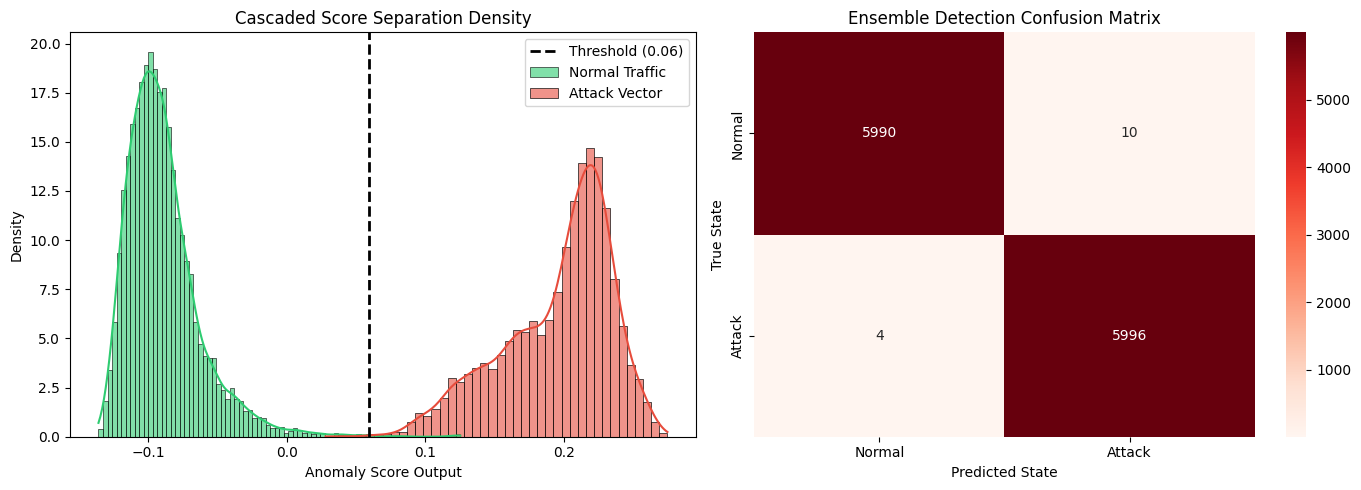

In [12]:
# Cell 5: Evaluation Engine using Attack Samples (With Proper Scaler Alignment)
import os  # Explicitly importing os to ensure smooth notebook execution
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def load_attack_samples(data_path='./datasets/', samples_per_file=3000):
    """Loads and isolates the attack files using the exact same structure."""
    files = {
        'a5': 'attack_samples_5sec.csv', 
        'a10': 'attack_samples_10sec.csv'
    }
    dfs = []
    for key, fname in files.items():
        path = os.path.join(data_path, fname)
        if not os.path.exists(path): 
            continue
        temp_df = pd.read_csv(path)
        temp_df = temp_df.sample(n=min(samples_per_file, len(temp_df)), random_state=42)
        temp_df["label"] = 1  # Malicious / Attack
        dfs.append(temp_df)
        
    if not dfs:
        raise FileNotFoundError("Attack files were not discovered in the target dataset directory.")
        
    return pd.concat(dfs, ignore_index=True)

# =====================================================================
# 1. Load Attack Samples & Align Columns with Trained Model
# =====================================================================
print(">>> Extracting Attack Sample Data Pools...")
raw_attack_df = load_attack_samples()

# Align categorical variables to codes matches
for col in raw_attack_df.select_dtypes(include=['object', 'category']).columns:
    if col != "label":
        raw_attack_df[col] = raw_attack_df[col].astype("category").cat.codes

# Match features exactly to the trained pipeline features (from df inside Cell 2)
trained_features = [col for col in df.columns if col != "label"]
X_attack_raw = raw_attack_df[trained_features].fillna(0).values
y_attack = raw_attack_df["label"].values

# CRITICAL FIX: Transform the raw attack data using the global MinMaxScaler instance from Cell 2
X_attack_scaled = scaler.transform(X_attack_raw)

# =====================================================================
# 2. Build the Mixed Validation Evaluation Dataset
# =====================================================================
# X_test is already scaled from Cell 2, and X_attack_scaled is now aligned.
X_eval_mixed = np.vstack((X_test, X_attack_scaled))
y_eval_mixed = np.concatenate((np.zeros(len(X_test)), y_attack))

print(f"    • Mixed Evaluation Pool Size: {X_eval_mixed.shape[0]} samples")
print(f"      - Normal Verification Baselines: {len(X_test)}")
print(f"      - Unseen Attack Instances:        {len(X_attack_scaled)}")

# =====================================================================
# 3. Generate Cascaded Anomaly Evaluation Scores
# =====================================================================
print("\n>>> Streaming Mixed Test Vectors to Trained Cascaded Framework...")
# Unpacking the tuple since compute_anomaly_scores returns (scores, hidden_embeddings)
eval_scores, eval_hidden_layers = pipeline.compute_anomaly_scores(X_eval_mixed)

# =====================================================================
# 4. Compute Metrics and Threshold Tuning
# =====================================================================
# Identify optimal alarm thresholds using precision-recall optimization profiles
precision, recall, thresholds = precision_recall_curve(y_eval_mixed, eval_scores)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
optimal_threshold = thresholds[np.argmax(f1_scores)]

y_predicted = (eval_scores > optimal_threshold).astype(int)

print("\n" + "="*50 + "\n   CASCADED ONE-CLASS DETECTION REPORT (WITH ATTACKS)\n" + "="*50)
print(classification_report(y_eval_mixed, y_predicted, digits=4, target_names=["Normal", "Attack"]))
print(f"Area Under ROC Curve (ROC-AUC Score): {roc_auc_score(y_eval_mixed, eval_scores):.4f}")
print(f"Calculated Optimal Threshold:       {optimal_threshold:.4f}")
print("="*50)

# =====================================================================
# 5. Visualization Dashboard
# =====================================================================
plt.figure(figsize=(14, 5))

# Plot 1: Score Separation Distributions
plt.subplot(1, 2, 1)
sns.histplot(eval_scores[y_eval_mixed == 0], color="#2ecc71", label="Normal Traffic", kde=True, stat="density", alpha=0.6)
sns.histplot(eval_scores[y_eval_mixed == 1], color="#e74c3c", label="Attack Vector", kde=True, stat="density", alpha=0.6)
plt.axvline(optimal_threshold, color='black', linestyle='--', lw=2, label=f'Threshold ({optimal_threshold:.2f})')
plt.title("Cascaded Score Separation Density")
plt.xlabel("Anomaly Score Output")
plt.ylabel("Density")
plt.legend()

# Plot 2: Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_eval_mixed, y_predicted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
plt.title("Ensemble Detection Confusion Matrix")
plt.xlabel("Predicted State")
plt.ylabel("True State")

plt.tight_layout()
plt.show()

In [16]:
# Cell 4: View Complete Dataset Features List
import pandas as pd

def display_all_dataset_features(dataframe):
    # Filter out the ground truth label column to isolate features
    feature_columns = [col for col in dataframe.columns if col != "label"]
    
    print("=" * 75)
    print(f"      COMPLETE DATASET FEATURE REGISTER (Total: {len(feature_columns)} Features)")
    print("=" * 75)
    
    # Generate a tracking breakdown table
    feature_data = []
    for idx, col_name in enumerate(feature_columns):
        feature_data.append({
            "Index": idx,
            "Feature Name": col_name,
            "Data Type": str(dataframe[col_name].dtype),
            "Unique Values": dataframe[col_name].nunique(),
            "Sample Value": dataframe[col_name].iloc[0]
        })
    
    # Convert to DataFrame for clean tabular rendering in your notebook
    features_registry_df = pd.DataFrame(feature_data)
    
    # Configure pandas to render flawlessly without truncating rows or column strings
    with pd.option_context(
        'display.max_rows', None, 
        'display.max_columns', None, 
        'display.colheader_justify', 'left'
    ):
        # Using Jupyter's native display system for high-quality HTML styling
        try:
            from IPython.display import display
            display(features_registry_df.set_index('Index'))
        except ImportError:
            print(features_registry_df.to_string(index=False))
        
    print("=" * 75)

# Run the display tool on your processed feature matrix
display_all_dataset_features(df)

      COMPLETE DATASET FEATURE REGISTER (Total: 39 Features)


,Feature Name,Data Type,Unique Values,Sample Value
Index,,,,
0,timestamp_start,int16,720,56.000000
1,log_data-ranges_avg,float64,860,0.000000
2,log_data-ranges_std_deviation,float64,1990,0.000000
3,log_data-types,int8,6,5.000000
4,log_interval-messages,float64,644,0.000000
5,log_messages_count,int64,54,0.000000
6,network_header-length_avg,float64,40,20.000000
7,network_header-length_std_deviation,float64,37,0.000000
8,network_interval-packets,float64,9597,5711.000000


In [19]:
# Cell 6: Model Export Engine for Production Deployment (Export Folder Version)
import os
import torch
import joblib

print("="*60)
print("   COMMENCING PRODUCTION EXPORT ENGINE")
print("="*60)

# Create the export directory if it doesn't exist
export_dir = "./export"
if not os.path.exists(export_dir):
    os.makedirs(export_dir)
    print(f"--> Created target folder: '{export_dir}'")

# 1. Export the PyTorch GRU Neural Network Weights
torch_model_path = os.path.join(export_dir, "gru_feature_extractor.pth")
torch.save(pipeline.feature_extractor.state_dict(), torch_model_path)
print(f"--> [SUCCESS] PyTorch GRU Weights exported to: '{torch_model_path}'")

# 2. Export the Sklearn Components together in a dictionary
artifacts = {
    "scaler": scaler,
    "anomaly_classifier": pipeline.anomaly_classifier,
    "window_size": pipeline.window_size,
    "input_dim": pipeline.input_dim,
    "hidden_dim": pipeline.hidden_dim
}
sklearn_artifacts_path = os.path.join(export_dir, "pipeline_artifacts.joblib")
joblib.dump(artifacts, sklearn_artifacts_path)
print(f"--> [SUCCESS] Sklearn Scaler & Ensemble exported to: '{sklearn_artifacts_path}'")
print("="*60)
print(f"DECOUPLED ARTIFACTS SUCCESSFULLY SAVED TO: {export_dir}/")
print("="*60)

   COMMENCING PRODUCTION EXPORT ENGINE
--> Created target folder: './export'
--> [SUCCESS] PyTorch GRU Weights exported to: './export/gru_feature_extractor.pth'
--> [SUCCESS] Sklearn Scaler & Ensemble exported to: './export/pipeline_artifacts.joblib'
DECOUPLED ARTIFACTS SUCCESSFULLY SAVED TO: ./export/
